## Make plots for publications

### 1. Compare count of all classified SNe to those in our sample

SNII 2114 275
SESNe 804 152
SNIIn 378 72


INFO:caat.SNCollection:Loading SN Type: Other, Subtype: SNIa
INFO:caat.SNCollection:['SN2017jdx' 'SN2017hgz' 'SN2020lil' 'SN2010ev' 'SN2010fy' 'SN2016eja'
 'SN2016hpw' 'SN2012G' 'SN2007gi' 'SN2016huh' 'SN2023ext' 'SN2017daf'
 'SN2021pfs' 'SN2021gma' 'SN2017bkc' 'SN2007bm' 'SN2021xju' 'SN2023lnh'
 'SN2020nlb' 'SN2017exo' 'SN2012cp' 'SN2017cqe' 'SN2017cts' 'SN2016gfr'
 'SN2017dhr' 'SN2009gf' 'SN2010ih' 'SN2017awk' 'SN2021fxy' 'SN2018oh'
 'SN2021ghc' 'SN2017gxq' 'SN2017yv' 'SN2007ax' 'SN2012fr' 'SN2021oat'
 'SN2021aefx' 'SN2023cqc' 'SN2018evt' 'SN2021lxb' 'SN2014J' 'SN2018feb'
 'SN2017atv' 'SN2019odh' 'SN2016cwf' 'SN2011aa' 'SN2017bzc' 'SN2020ssf'
 'SN2023hsw' 'SN2020szr' 'SN2022zut' 'SN2023hsy' 'SN2011ao' 'SN2021skf'
 'SN2023gft' 'SN2006E' 'SN2021smj' 'SN2011de' 'SN2013dh' 'SN2020rlj'
 'SN2017dps' 'SN2011at' 'SN2021dov' 'SN2016ito' 'SN2016gxp' 'SN2019ozb'
 'SN2017hm' 'SN2006X' 'SN2013gs' 'SN2020aatc' 'SN2023hzy' 'SN2017bc'
 'SN2018xx' 'SN2018zz' 'SN2016ipf' 'SN2018yu' 'SN2020rgz' 'SN2018

SLSN-I 131 54
SLSN-II 62 18
FBOT 56 31
SNIa 8954 329


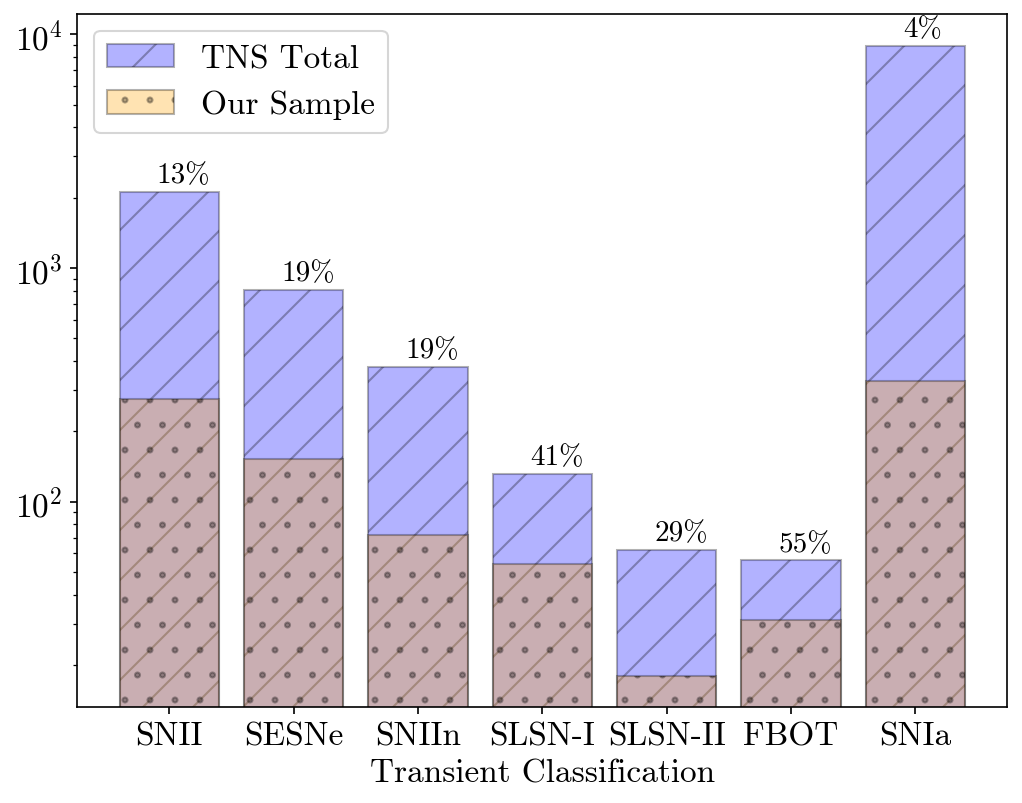

In [ ]:
import pandas as pd
from caat.utils import ROOT_DIR
from caat import SNType, SNCollection
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

rc('font', **{'family': 'serif', 'serif': ['cmr10']})
matplotlib.rcParams['axes.unicode_minus'] = False


tns_df = pd.read_csv(ROOT_DIR + '/data/tns_public_objects.csv', header=0)

def count_tns_objs(tns_df, cls):
    if cls != "SNIa":
        snsubtypes_per_type = {
            "SESNe": ['SN Ib', 'SN IIb', "SN Ic", "SN Ic-BL"],
            "SNII": ["SN II", "SN IIP", "SN II-pec"],
            "FBOT": ["SN Ibn", "SN Icn"],
            "SLSN-I": ["SLSN-I"],
            "SLSN-II": ["SLSN-II"],
            "SNIIn": ["SN IIn"],
            # "Other": ["SN Ia", "SN Ia-91bg-like", "SN Ia-CSM", "SN Ia-91T-like", "SN Ia-pec", "SN Iax", "TDE"]
        }
        sncollection = SNType(type=cls)
        caat_count = len(sncollection.sne)

    else:
        snsubtypes_per_type = {
            "SNIa": ["SN Ia", "SN Ia-91bg-like", "SN Ia-CSM", "SN Ia-91T-like", "SN Ia-pec", "SN Iax"]
        }
        sncollection = SNCollection(sntype="Other", snsubtype="SNIa")
        caat_count = len(sncollection.sne)

    filtered_df = tns_df[(tns_df['creationdate'] < '2023-08-01 00:00:00') & (tns_df['type'].isin(snsubtypes_per_type[cls]))]
    df_count = len(filtered_df)
    return df_count, caat_count

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
for i, cls in enumerate(["SNII", "SESNe", "SNIIn", "SLSN-I", "SLSN-II", "FBOT", "SNIa"]):
    df_count, caat_count = count_tns_objs(tns_df, cls)
    print(cls, df_count, caat_count)
    if cls == "SNII":
        ax.bar(cls, [df_count, caat_count], align="center", color=["blue", "orange"], edgecolor='k', alpha=0.3, hatch=['/', '.'], label=["TNS Total", "Our Sample"])
    else:
        ax.bar(cls, [df_count, caat_count], align="center", color=["blue", "orange"], edgecolor='k', alpha=0.3, hatch=['/', '.'])

    ax.text(i-0.1, df_count*1.1, f"{caat_count/df_count*100:.0f}%", fontsize=14)

ax.set_xlabel("Transient Classification")
ax.legend()
ax.set_yscale("log")
# plt.savefig("/Users/craigpellegrino/work/presentations/aas247/objects_per_type.pdf")
plt.show()


### 2. Plot number of data points at each epoch for each transient classification

SNII: 13781
SESNe: 5049
SNIIn: 2997
SLSN-I: 3443
SLSN-II: 760
FBOT: 3297
Other: 17016


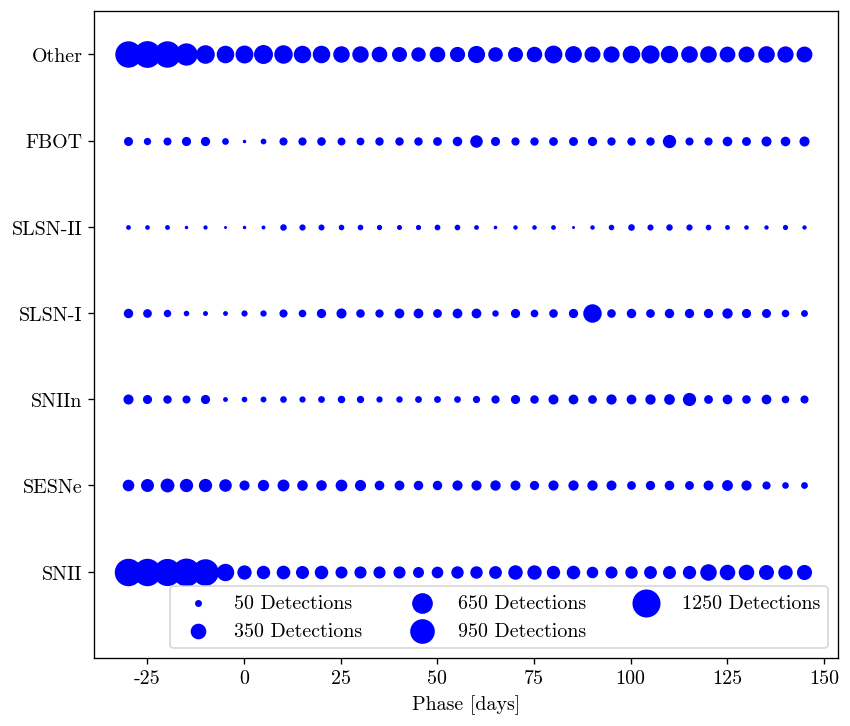

Total number of counts:  46343


In [5]:
import os
import numpy as np
from caat import SNType
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10']})

def bin_detections_per_class(cls, detections=True):
    sncollection = SNType(type=cls)
    counts = {}
    for sn in sncollection.sne:
        data_cube_filename = os.path.join(
            sn.base_path,
            sn.classification,
            sn.subtype,
            sn.name,
            sn.name + "_datacube_mangled.csv"
        )
        if os.path.exists(data_cube_filename):
            cube = pd.read_csv(data_cube_filename)
            if detections:
                dets = cube[cube["Nondetection"] == False]
            else:
                dets = cube[cube["Nondetection"] == True]
            for phase in np.arange(-30, 150, 5):
                dets_at_phase = dets[abs(dets["Phase"] - phase) < 2.5]
                counts.setdefault(phase, 0)
                counts[phase] += len(dets_at_phase)
    return counts

fig, ax = plt.subplots(figsize=(8, 7), dpi=120)
total_counts = 0
for i, cls in enumerate(["SNII", "SESNe", "SNIIn", "SLSN-I", "SLSN-II", "FBOT", "Other"]):
    total_counts_per_cls = 0
    counts_per_cls = bin_detections_per_class(cls, detections=True)
    for phase, counts in counts_per_cls.items():
        ax.scatter(phase, i, marker='o', color='blue', s=counts/5)
        total_counts += counts
        total_counts_per_cls += counts
    print(f"{cls}: {total_counts_per_cls}")

ax.set_yticks(
    [0, 1, 2, 3, 4, 5, 6],
    ["SNII", "SESNe", "SNIIn", "SLSN-I", "SLSN-II", "FBOT", "Other"],
)
for count in np.arange(50, 1550, 300):
    ax.scatter([], [], color='blue', marker='o', s=count/5, label=f"{count} Detections")
ax.set_ylim(-1., 6.5)
ax.legend(loc=4, ncols=3)
ax.set_xlabel("Phase [days]")
# plt.savefig("/Users/craigpellegrino/work/gopreaux_papers/paper_1/figures/data_per_phase.pdf")
plt.show()
print("Total number of counts: ", total_counts)

### 2.1 Plot number of data points for each filter as function of phase

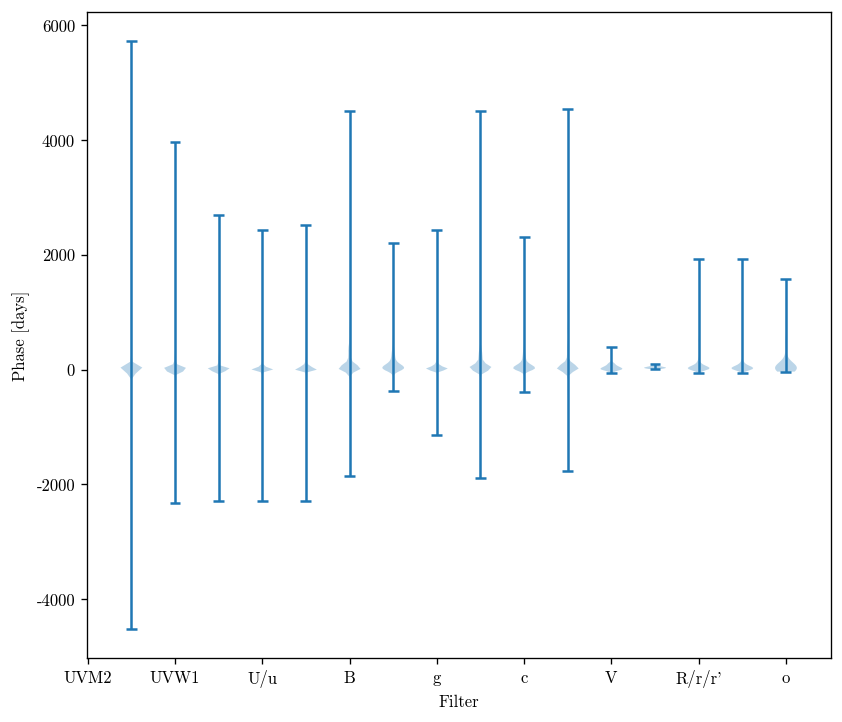

In [ ]:
import os
import numpy as np
from caat import SNType
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10']})

def bin_detections_per_filter(filts: list, detections=True):
    counts = []
    for i, cls in enumerate(["SNII", "SESNe", "SNIIn", "SLSN-I", "SLSN-II", "FBOT", "Other"]):
        sncollection = SNType(type=cls)
        for sn in sncollection.sne:
            data_cube_filename = os.path.join(
                sn.base_path,
                sn.classification,
                sn.subtype,
                sn.name,
                sn.name + "_datacube_mangled.csv"
            )
            if os.path.exists(data_cube_filename):
                cube = pd.read_csv(data_cube_filename)
                if detections:
                    dets = cube[(cube["Nondetection"] == False) & (cube["Filter"].isin(filts))]
                else:
                    dets = cube[(cube["Nondetection"] == True) & (cube["Filter"].isin(filts))]
                counts.extend(dets["Phase"].values)
                # for phase in np.arange(-30, 150, 5):
                #     dets_at_phase = dets[abs(dets["Phase"] - phase) < 2.5]
                #     counts.setdefault(phase, 0)
                #     counts[phase] += len(dets_at_phase)
    return counts

fig, ax = plt.subplots(figsize=(8, 7), dpi=120)

all_counts = []
labels = []
for filts in [
    ["UVW2"],
    ["UVM2"],
    ["UVW1"],
    ["U", "u"],
    ["B"],
    ["g"],
    ["c"],
    ["V"],
    ["R", "r", "r'"],
    ["o"],
    ["I", "i", "i'"],
    ["z", "z'"],
    ["y", "y'"],
    ["J"],
    ["H"],
    ["K"],
    ["I1"],
    ["I2"],
    ["I3"],
    ["I4"],
]:
    counts_per_filt = bin_detections_per_filter(filts, detections=True)
    if len(counts_per_filt) > 0:
        all_counts.append(counts_per_filt)
        labels.append("/".join(filt for filt in filts))

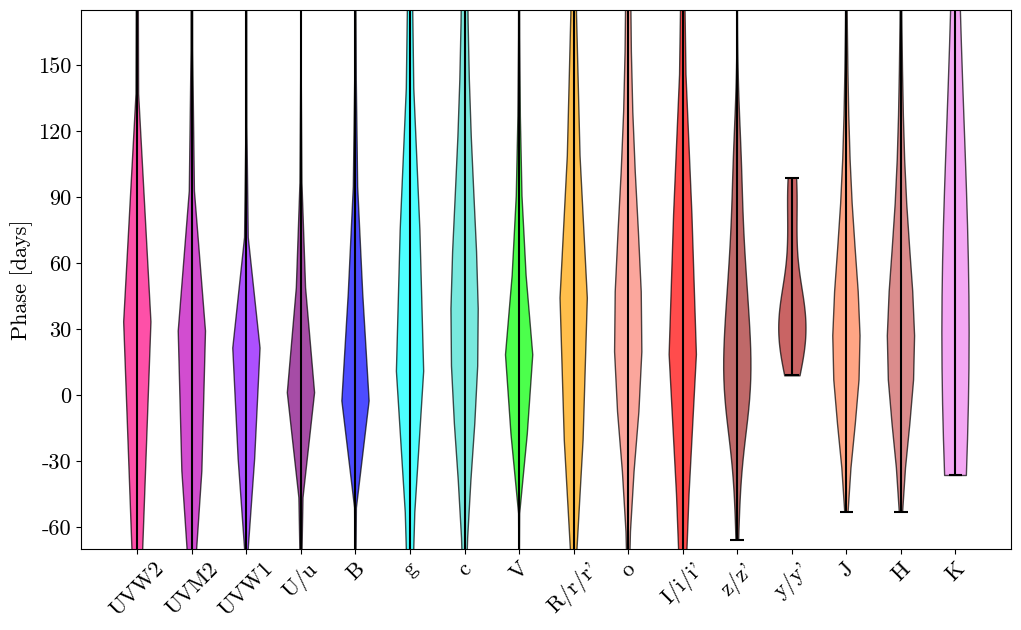

In [ ]:
from caat.utils import colors

fig, ax = plt.subplots(figsize=(12, 7))

vp = ax.violinplot(all_counts)
new_colors = ["brown", "firebrick", "coral", "indianred", "violet", "orange"]
for pc, label in zip(vp['bodies'], labels):
    color = None
    for filt in label.split('/'):
        if filt in colors.keys():
            color = colors[filt]
            break
    if not color:
        color = new_colors[0]
        new_colors = new_colors[1:]
    
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

vp['cmaxes'].set_edgecolor('black')
vp['cmins'].set_edgecolor('black')
vp['cbars'].set_edgecolor('black')

ax.set_xticks(np.arange(len(labels)) + 1)
ax.set_xticklabels(labels, rotation=45, fontsize=16)

yticks = np.arange(-60, 180, 30)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize=16)

ax.set_ylim(-70.0, 175.0)
ax.set_ylabel("Phase [days]", fontsize=16)
# plt.savefig("/Users/craigpellegrino/work/gopreaux_papers/paper_1/figures/data_per_filter.pdf")
plt.show()

### 3. Plot example fit for max

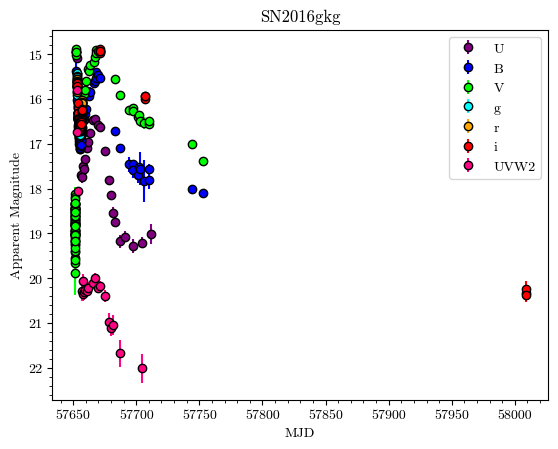

INFO:caat.SN:Data in filters ['G', 'V', 'Clear', 'C', 'B', 'I', 'g', 'r', 'i', 'R', 'clear', 'y', 'z', 'UVW2', 'U']



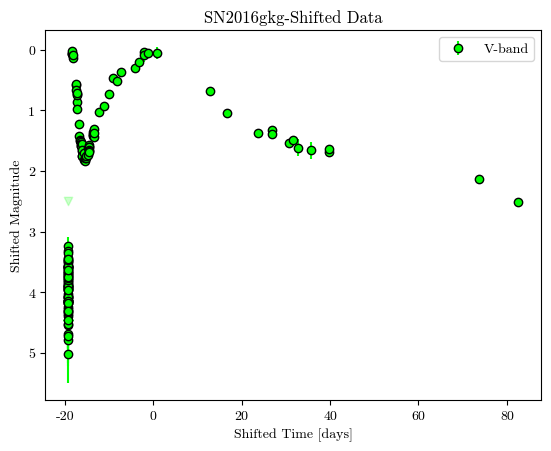

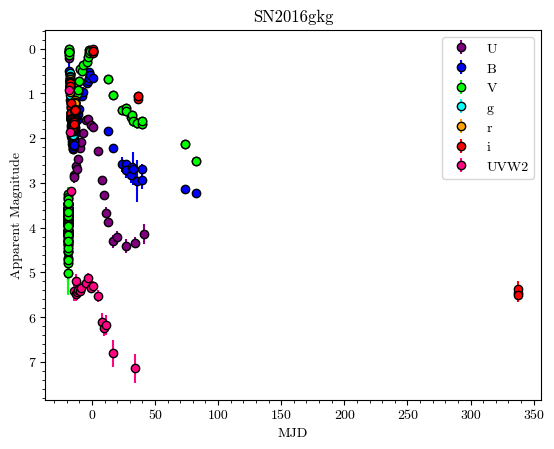

INFO:caat.SN:To save these parameters, rerun with "save_to_caat=True"


In [11]:
from caat import SN

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10']})

sn = SN(name="SN2016gkg")
sn.interactively_fit_for_max(plot=True)

### 4. Plot warped datacube

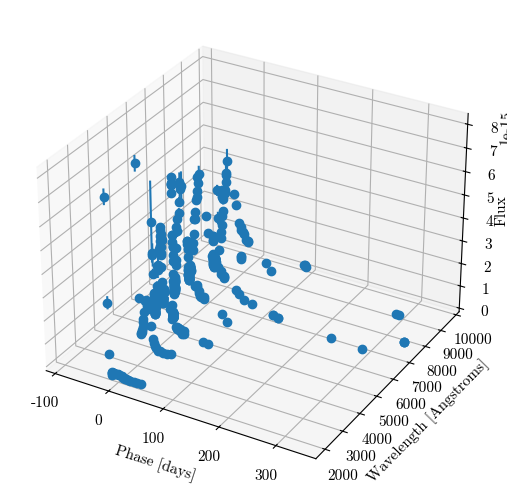

In [64]:
from caat import DataCube, SN
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 11})


sn = SN(name="SN2016gkg")
cube = DataCube(sn=sn)
ax = cube.plot_cube()
# ax.set_xlim(-20, 100)
ax.set_xlabel("Phase [days]")
ax.set_ylabel("Wavelength [Angstroms]")
ax.set_zlabel("Flux", rotation=90, labelpad=-4)
plt.tight_layout(pad=0)
# ax.zaxis.labelpad=-4.0
# ax.set_title(" " * 40)
plt.savefig('/Users/craigpellegrino/work/gopreaux_papers/paper_1/figures/datacube.pdf')

### 5. Comparing model prediction to photometry

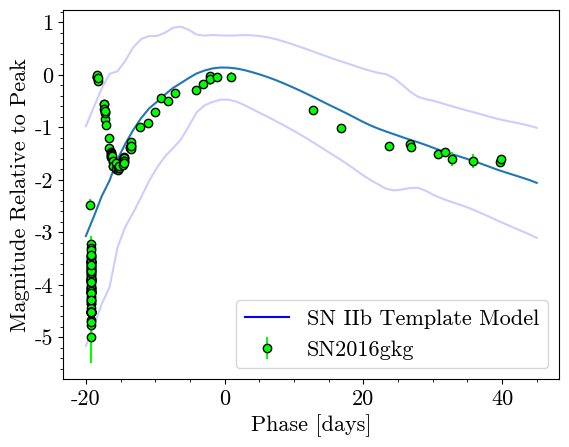

In [12]:
from caat import SNModel, SN
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 16})


model = SNModel(
    surface="SESNe_SNIIb_GP_model.fits",
)
model.predict_lightcurve(-20.0, 45.0, 6000, show=False)
gkg = SN(name="SN2016gkg")
model.compare_lightcurve_with_photometry(gkg, filt="V", show=False)
plt.plot([], [], color='blue', label="SN IIb Template Model")
plt.legend()
plt.ylabel("Magnitude Relative to Peak")
plt.xlabel("Phase [days]")
plt.minorticks_on()
plt.title("")
# plt.savefig("/Users/craigpellegrino/work/gopreaux_papers/paper_1/figures/model_compared_to_phot.pdf")
plt.show()

### 6. Simulate fitting light curves to photometry

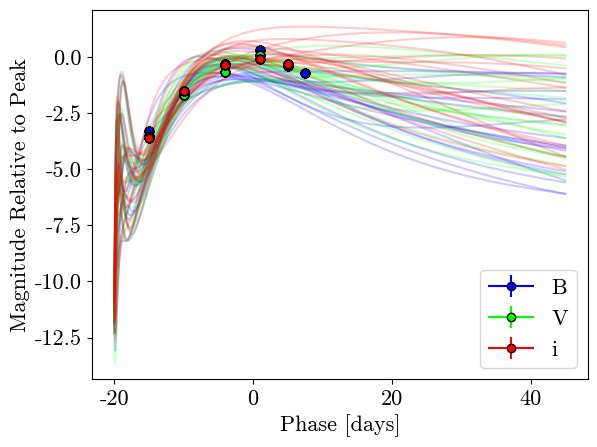

In [ ]:
from caat import SNModel
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 16})

model = SNModel(
    surface="SESNe_SNIIb_GP_model.fits",
)

# mock_photometry_values = {
#     "Filter": ["B", "B", "B", "B", "B", "V", "V", "V", "V", "V", "i", "i", "i", "i", "i", "B"],
#     "Phase": [-15.0, -10.0, -4.0, 1.0, 5.0, -15.0, -10.0, -4.0, 1.0, 5.0, -15.0, -10.0, -4.0, 1.0, 5.0, 30.0],
#     "Mag": [-3.3, -1.6, -0.8, 0.1, -0.6, -3.5, -1.7, -0.75, -0.1, -0.5, -3.6, -1.65, -0.4, 0.0, -0.4, -4.0],
#     "MagErr": [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
# }

mock_photometry_values = {
    "Filter": ["B", "B", "B", "B", "B", "V", "V", "V", "V", "V", "i", "i", "i", "i", "i", "B",],
    "Phase": [-15.0, -10.0, -4.0, 1.0, 5.0, -15.0, -10.0, -4.0, 1.0, 5.0, -15.0, -10.0, -4.0, 1.0, 5.0, 7.5,],
    "Mag": [-3.3, -1.6, -0.3, 0.3, -0.4, -3.5, -1.7, -0.65, 0.1, -0.3, -3.6, -1.5, -0.35, -0.1, -0.3, -0.7],
    "MagErr": [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
}

model.fit_photometry(
    photometry=mock_photometry_values, 
    phase_min=-20,
    phase_max=45,
    show=False,
    nsamples=20
)

plt.errorbar([], [], yerr=[], color='blue', mec='k', marker='o', label='B')
plt.errorbar([], [], yerr=[], color='lime', mec='k', marker='o', label='V')
plt.errorbar([], [], yerr=[], color='red', mec='k', marker='o', label='i')
plt.legend()

plt.xlabel("Phase [days]")
plt.ylabel("Magnitude Relative to Peak")
# plt.savefig("/Users/craigpellegrino/work/gopreaux_papers/paper_1/figures/synthetic_lcs.pdf")
plt.show()

### 7. Simulate Photometry Points

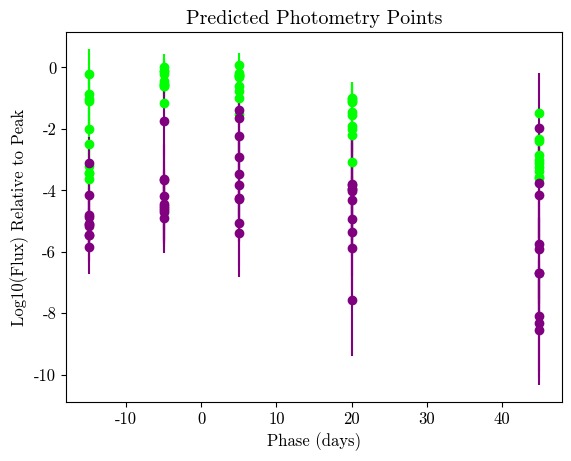

In [2]:
from caat import SNModel
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 12})

model = SNModel(
    surface="SESNe_SNIIb_GP_model.fits",
)

fig, ax = plt.subplots()

predictions = {'lime': 5000.0, 'purple': 2500.0}
phases = np.asarray([-15.0, -5.0, 5.0, 20.0, 45.0])
for color, wavelength in predictions.items():
    for i in range(10):
        model.predict_photometry_points(
            wavelengths=np.asarray([wavelength] * len(phases)),
            phases=phases,
            show=False,
            color=color,
        )
plt.show()

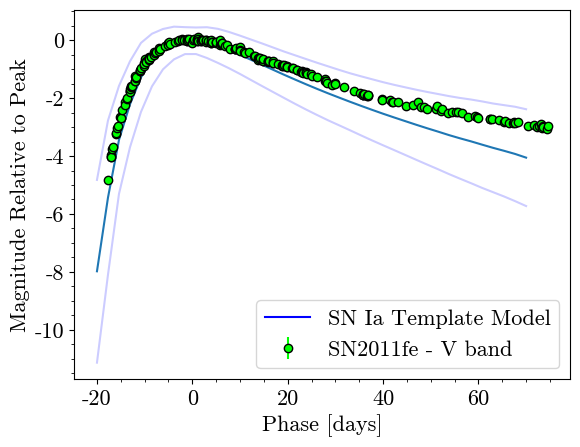

In [ ]:
from caat import DataCube, SNModel, SN
import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 16})


model = SNModel(
    surface="Other_SNIa_GP_model.fits",
)
model.predict_lightcurve(-20.0, 70.0, 6000, show=False)
sn = SN(name="SN2011fe")
model.compare_lightcurve_with_photometry(sn, filt="V", show=False)
plt.plot([], [], color='blue', label="SN Ia Template Model")
plt.legend()
plt.ylabel("Magnitude Relative to Peak")
plt.xlabel("Phase [days]")
plt.minorticks_on()
plt.title("")
# plt.savefig("/Users/craigpellegrino/work/presentations/aas247/model_compared_to_phot.pdf")
plt.show()


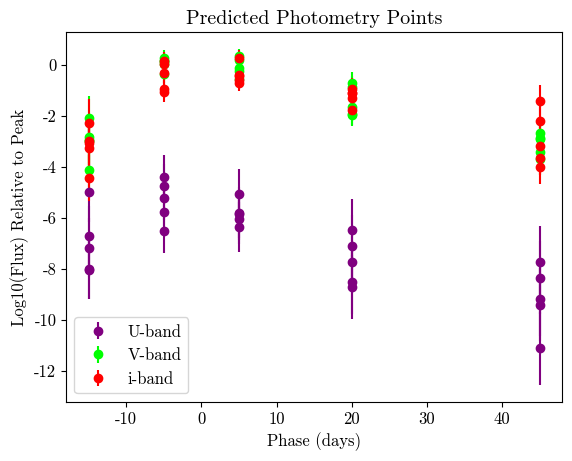

In [ ]:
from caat import SNModel
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 12})

model = SNModel(
    surface="Other_SNIa_GP_model.fits",
)

fig, ax = plt.subplots()

predictions = {'purple': 2500.0, 'lime': 5000.0, "red": 8000.0}
filts = {"lime": "V-band", "purple": "U-band", "red": "i-band"}
phases = np.asarray([-15.0, -5.0, 5.0, 20.0, 45.0])
for color, wavelength in predictions.items():
    for i in range(5):
        model.predict_photometry_points(
            wavelengths=np.asarray([wavelength] * len(phases)),
            phases=phases,
            show=False,
            color=color,
        )
    plt.errorbar([], [], yerr=[], fmt='o', color=color, label=filts[color])
plt.legend()
# plt.savefig("/Users/craigpellegrino/work/presentations/aas247/synthetic_phot.pdf")
plt.show()

### Plot polynomial mean function and data

INFO:caat.SNCollection:Loading SN Type: SESNe, Subtype: None
INFO:caat.SNCollection:['SN2016adj' 'SN2004dk' 'SN2019tsf' 'SN2010O' 'SN2022crv' 'SN2007C'
 'SN2021uhk' 'SN2019yvr' 'SN2023dtc' 'SN2019dge' 'SN2019dgz' 'SN2012au'
 'SN2009jf' 'SN2019oys' 'SN2018beh' 'SN2007uy' 'SN2022nyo' 'SN2021niq'
 'SN2011am' 'SN2021gno' 'SN2022hgk' 'SN2020hvp' 'SN2006dn' 'SN2017bgu'
 'SN2016bau' 'SN2010cn' 'SN2003gk' 'SN2019ehk' 'SN2008bo' 'SN2022ryd'
 'SN2018alc' 'SN2022ngb' 'SN2019wxt' 'SN2020sbw' 'SN2009mg' 'SN2021uqw'
 'SN2011hs' 'SN2020rsc' 'SN2022hnt' 'SN2021ybc' 'SN2016gkg' 'SN2021sjt'
 'SN2022eji' 'SN2020acat' 'SN2016bmd' 'SN2006T' 'SN2009gj' 'SN2009mk'
 'SN2020xlt' 'SN2020ikq' 'SN2021pb' 'SN2021bxu' 'SN2023aew' 'SN2020fqv'
 'SN2020jfv' 'SN2011cb' 'SN2022qzr' 'SN2017ati' 'SN2023mut' 'SN2019hte'
 'SN2019rn' 'SN2016iae' 'SN2021do' 'SN2012cw' 'SN2007D' 'SN2015fn'
 'SN2018lei' 'SN2020sgf' 'SN2010gx' 'SN2021afuq' 'SN2021dwg' 'SN2005ek'
 'SN2009mi' 'SN2019yz' 'SN2019cad' 'SN2010ah' 'SN2020lbh' 'SN2018av

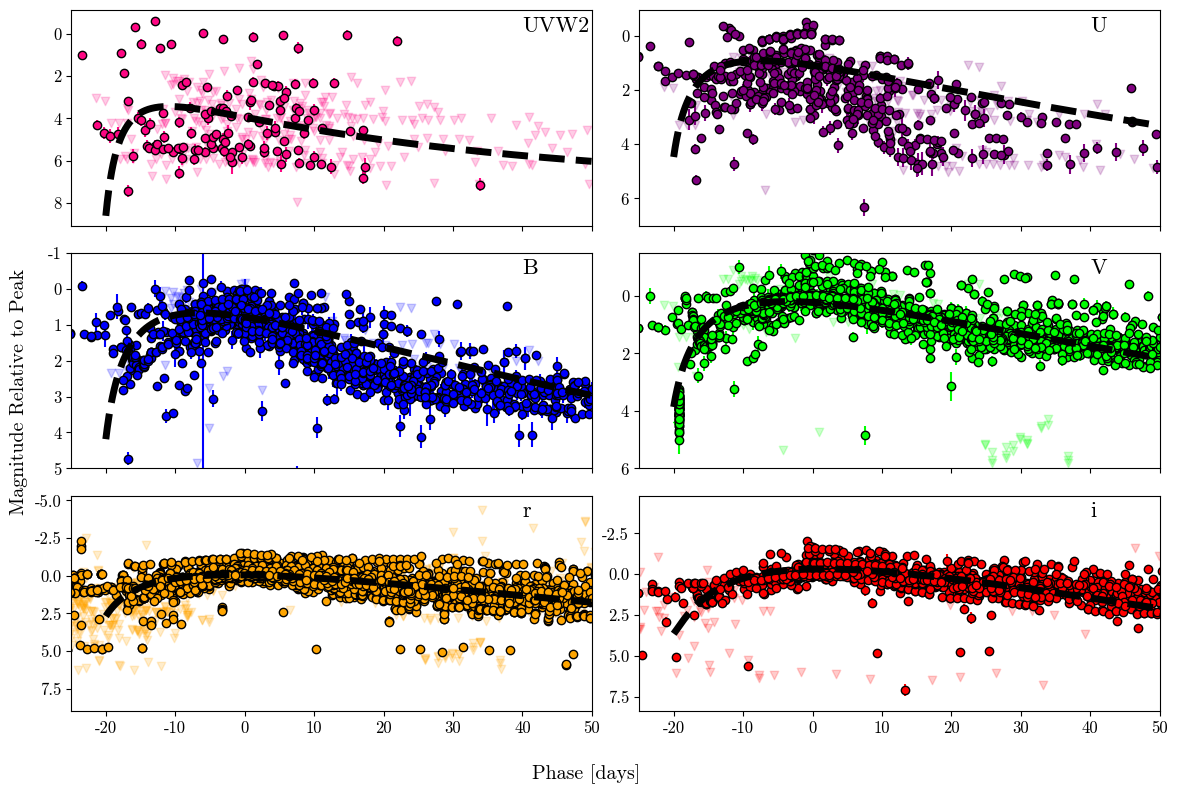

In [11]:
from caat import SNCollection, SNModel, SN
from caat.utils import WLE, convert_shifted_fluxes_to_shifted_mags
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rc
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', **{'family': 'serif', 'serif': ['cmr10'], 'size': 12})

typ = SNCollection(sntype="SESNe")
model = SNModel(surface="SESNe_SNIIb_GP_model.fits")

filts = np.asarray(["UVW2", "U", "B", "V", "r", "i"]).reshape(3,2)
fig, axes = plt.subplots(nrows=filts.shape[0], ncols=filts.shape[1], figsize=(12, 8), sharex=True)

for filt_row, ax_row in zip(filts, axes):
    for filt, ax in zip(filt_row, ax_row):
        ax = typ.plot_all_lcs(filts=[filt], ax=ax, show=False)

        # Get WL of current filt, plot polynomial template at that WL
        wl = WLE[filt]
        wl_ind = np.argmin(abs(model.wl_grid - wl))
        
        sn = SN(data={})
        sn.info = {"peak_filt": "V", "peak_mag": 17}
        polynomial_template = model.template[:, wl_ind]
        polynomial_template = convert_shifted_fluxes_to_shifted_mags(polynomial_template, sn, sn.zps[filt])

        ax.plot(model.phase_grid, polynomial_template * -1, color='black', linestyle='--', linewidth=5, zorder=5)

        ax.set_xlim(-25, 50)
        if filt == "B":
            ax.set_ylim(-1, 5)
        if filt == "V":
            ax.set_ylim(-1.5, 6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.invert_yaxis()
        ax.text(40, ax.get_ylim()[1] + abs((ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.1), filt, fontsize=16)

fig.supxlabel("Phase [days]")
fig.supylabel("Magnitude Relative to Peak")

plt.tight_layout()
# plt.savefig("/Users/craigpellegrino/work/gopreaux_papers/paper_1/figures/polynomial_templates.pdf")
plt.show()